### 森林防火

森林火灾数据集路径检查
项目根目录: D:\torch_env\森林火数据集
是否存在: True
原始数据目录: D:\torch_env\森林火数据集\fire_dataset
是否存在: True
有火图片目录 fire_images: D:\torch_env\森林火数据集\fire_dataset\fire_images
是否存在: True
没火图片目录 non_fire_images: D:\torch_env\森林火数据集\fire_dataset\non_fire_images
是否存在: True

图片数量统计：
有火图片数量: 755
没火图片数量: 244


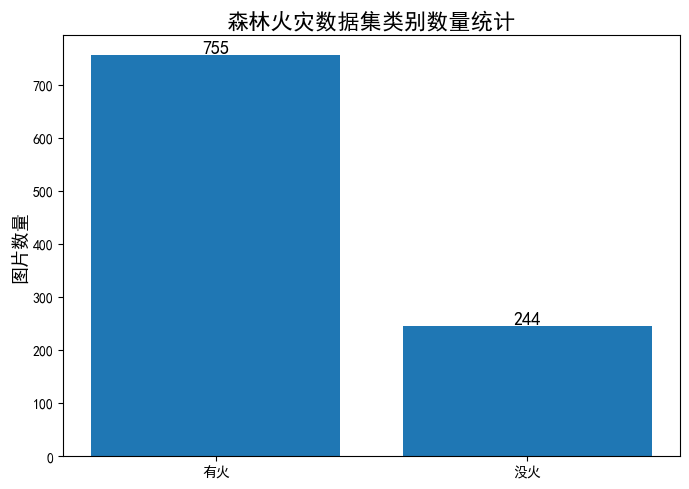

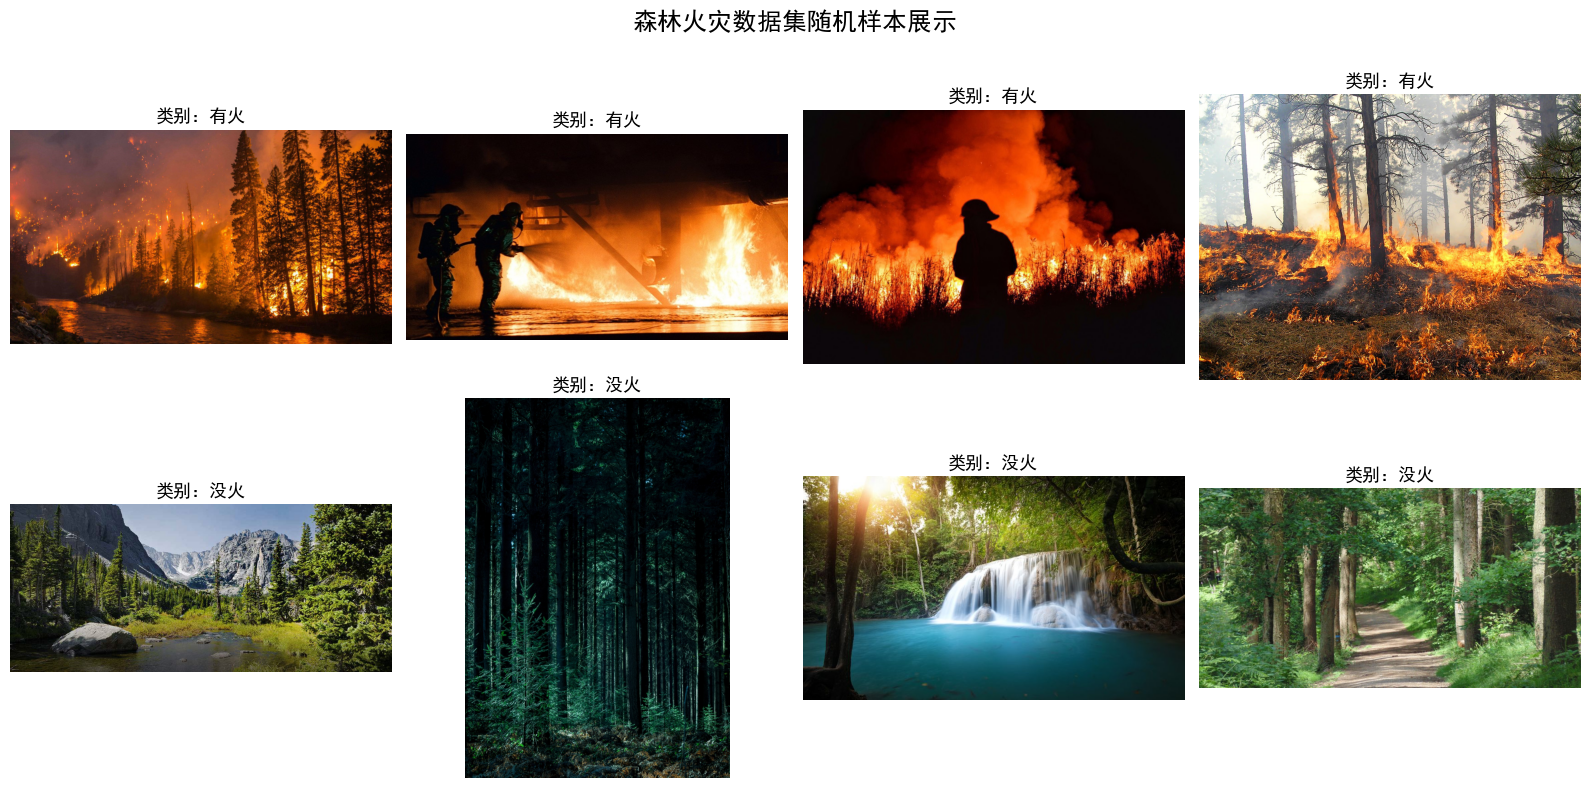


正在重新整理 YOLO 分类数据集...

整理完成：
有火 fire: {'train': 528, 'val': 151, 'test': 76}
没火 no_fire: {'train': 170, 'val': 49, 'test': 25}
训练集-有火: D:\torch_env\森林火数据集\yolo_fire_cls_dataset\train\fire
是否存在: True
训练集-没火: D:\torch_env\森林火数据集\yolo_fire_cls_dataset\train\no_fire
是否存在: True
验证集-有火: D:\torch_env\森林火数据集\yolo_fire_cls_dataset\val\fire
是否存在: True
验证集-没火: D:\torch_env\森林火数据集\yolo_fire_cls_dataset\val\no_fire
是否存在: True

找到本地分类模型: D:\torch_env\yolo11n-cls.pt

森林火灾 YOLO 分类训练配置
当前设备: CPU
模型文件: D:\torch_env\yolo11n-cls.pt
数据目录: D:\torch_env\森林火数据集\yolo_fire_cls_dataset
训练轮次: 5
图片尺寸: 224
批大小: 8
训练结果目录: D:\torch_env\森林火数据集\runs\classify\forest_fire_cls_train
Ultralytics 8.4.82  Python-3.10.20 torch-2.12.1+cpu CPU (AMD Ryzen 7 H 255 W/ Radeon 780M)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_m

In [ ]:
%matplotlib inline

# ============================================================
# 森林火灾识别 YOLO 分类完整代码
# 功能：
# 1. 按你的真实路径读取森林火数据集
# 2. 自动把 fire_images / non_fire_images 整理成 YOLO 分类格式
# 3. 训练森林火灾二分类模型
# 4. 随机测试几张图片
# 5. 显示预测类别、置信度、实际类别
# 6. 生成类别数量图、样本展示图、训练曲线图、测试结果可视化图
# ============================================================

import os
import random
import shutil
import warnings
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from ultralytics import YOLO

warnings.filterwarnings("ignore")
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# ============================================================
# 1. 基础路径配置：这里已经按你的截图修改好了
# ============================================================

ROOT_DIR = Path(r"D:\torch_env\森林火数据集")

# 原始数据目录
RAW_DATA_DIR = ROOT_DIR / "fire_dataset"

# 有火图片目录
FIRE_SRC_DIR = RAW_DATA_DIR / "fire_images"

# 没火图片目录
NO_FIRE_SRC_DIR = RAW_DATA_DIR / "non_fire_images"

# 自动整理后的 YOLO 分类数据集目录
CLS_DATA_DIR = ROOT_DIR / "yolo_fire_cls_dataset"

# 训练结果保存目录
PROJECT_DIR = ROOT_DIR / "runs" / "classify"
RUN_NAME = "forest_fire_cls_train"

# 检测结果保存目录
RESULT_SAVE_DIR = ROOT_DIR / "森林火检测结果_中文"
RESULT_SAVE_DIR.mkdir(parents=True, exist_ok=True)

# 是否重新整理数据集
# 第一次运行建议 True
# 后面如果已经整理好了，可以改成 False
REBUILD_DATASET = True

# 快速跑通参数
# 想快点出截图：EPOCHS = 3
# 想效果好一点：EPOCHS = 20 或 50
EPOCHS = 5
IMG_SIZE = 224
BATCH_SIZE = 8

# 随机测试图片数量
TEST_NUM = 6

# 类别中英文映射
CLASS_CN = {
    "fire": "有火",
    "no_fire": "没火",
}

# 支持的图片格式
IMG_SUFFIXES = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]


# ============================================================
# 2. 中文字体设置
# ============================================================

def get_chinese_font(size=28):
    """
    自动寻找 Windows 中文字体，防止中文显示成方块。
    """
    font_candidates = [
        r"C:\Windows\Fonts\simhei.ttf",
        r"C:\Windows\Fonts\msyh.ttc",
        r"C:\Windows\Fonts\simsun.ttc",
        r"D:\torch_env\SimHei.ttf",
    ]

    for font_path in font_candidates:
        if os.path.exists(font_path):
            return ImageFont.truetype(font_path, size=size)

    return ImageFont.load_default()


plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False


# ============================================================
# 3. 路径检查
# ============================================================

def check_dir(path, name):
    print(f"{name}: {path}")
    print(f"是否存在: {path.exists()}")
    if not path.exists():
        raise FileNotFoundError(f"{name}不存在，请检查路径：{path}")


print("=" * 90)
print("森林火灾数据集路径检查")
print("=" * 90)

check_dir(ROOT_DIR, "项目根目录")
check_dir(RAW_DATA_DIR, "原始数据目录")
check_dir(FIRE_SRC_DIR, "有火图片目录 fire_images")
check_dir(NO_FIRE_SRC_DIR, "没火图片目录 non_fire_images")


def get_images(folder):
    images = []
    for suffix in IMG_SUFFIXES:
        images.extend(list(folder.glob(f"*{suffix}")))
        images.extend(list(folder.glob(f"*{suffix.upper()}")))
    return sorted(list(set(images)))


fire_images = get_images(FIRE_SRC_DIR)
no_fire_images = get_images(NO_FIRE_SRC_DIR)

print("\n图片数量统计：")
print("有火图片数量:", len(fire_images))
print("没火图片数量:", len(no_fire_images))

if len(fire_images) == 0:
    raise RuntimeError(f"有火图片目录为空：{FIRE_SRC_DIR}")

if len(no_fire_images) == 0:
    raise RuntimeError(f"没火图片目录为空：{NO_FIRE_SRC_DIR}")


# ============================================================
# 4. 显示类别数量柱状图
# ============================================================

plt.figure(figsize=(7, 5))
plt.bar(["有火", "没火"], [len(fire_images), len(no_fire_images)])
plt.title("森林火灾数据集类别数量统计", fontsize=16)
plt.ylabel("图片数量", fontsize=13)

for i, v in enumerate([len(fire_images), len(no_fire_images)]):
    plt.text(i, v, str(v), ha="center", va="bottom", fontsize=13)

plt.tight_layout()
plt.show()


# ============================================================
# 5. 展示部分原始样本图
# ============================================================

def show_raw_samples():
    sample_fire = random.sample(fire_images, min(4, len(fire_images)))
    sample_no_fire = random.sample(no_fire_images, min(4, len(no_fire_images)))

    samples = [(p, "有火") for p in sample_fire] + [(p, "没火") for p in sample_no_fire]

    plt.figure(figsize=(16, 8))

    for i, (img_path, label) in enumerate(samples):
        img = Image.open(img_path).convert("RGB")

        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        plt.title(f"类别：{label}", fontsize=13)
        plt.axis("off")

    plt.suptitle("森林火灾数据集随机样本展示", fontsize=18)
    plt.tight_layout()
    plt.show()


show_raw_samples()


# ============================================================
# 6. 自动整理成 YOLO 分类数据集格式
# YOLO 分类格式：
# yolo_fire_cls_dataset/
#   train/
#     fire/
#     no_fire/
#   val/
#     fire/
#     no_fire/
#   test/
#     fire/
#     no_fire/
# ============================================================

def copy_split_images(image_list, class_name, train_ratio=0.7, val_ratio=0.2):
    """
    将一个类别的图片随机划分到 train / val / test。
    """
    image_list = image_list.copy()
    random.shuffle(image_list)

    total = len(image_list)
    train_end = int(total * train_ratio)
    val_end = int(total * (train_ratio + val_ratio))

    split_data = {
        "train": image_list[:train_end],
        "val": image_list[train_end:val_end],
        "test": image_list[val_end:]
    }

    for split_name, split_images in split_data.items():
        target_dir = CLS_DATA_DIR / split_name / class_name
        target_dir.mkdir(parents=True, exist_ok=True)

        for src_path in split_images:
            dst_path = target_dir / src_path.name
            shutil.copy2(src_path, dst_path)

    return {
        "train": len(split_data["train"]),
        "val": len(split_data["val"]),
        "test": len(split_data["test"])
    }


if REBUILD_DATASET:
    print("\n正在重新整理 YOLO 分类数据集...")

    if CLS_DATA_DIR.exists():
        shutil.rmtree(CLS_DATA_DIR)

    random.seed(42)

    fire_split = copy_split_images(fire_images, "fire")
    no_fire_split = copy_split_images(no_fire_images, "no_fire")

    print("\n整理完成：")
    print("有火 fire:", fire_split)
    print("没火 no_fire:", no_fire_split)
else:
    print("\n跳过数据集整理，直接使用已有目录：", CLS_DATA_DIR)

check_dir(CLS_DATA_DIR / "train" / "fire", "训练集-有火")
check_dir(CLS_DATA_DIR / "train" / "no_fire", "训练集-没火")
check_dir(CLS_DATA_DIR / "val" / "fire", "验证集-有火")
check_dir(CLS_DATA_DIR / "val" / "no_fire", "验证集-没火")


# ============================================================
# 7. 自动寻找分类模型
# 优先找本地模型，找不到就让 YOLO 自动下载 yolo11n-cls.pt
# ============================================================

MODEL_CANDIDATES = [
    ROOT_DIR / "yolo11n-cls.pt",
    ROOT_DIR / "yolov8n-cls.pt",
    Path(r"D:\torch_env\yolo11n-cls.pt"),
    Path(r"D:\torch_env\yolov8n-cls.pt"),
    Path(r"D:\torch_env\森林火数据集\yolo11n-cls.pt"),
    Path(r"D:\torch_env\森林火数据集\yolov8n-cls.pt"),
]

MODEL_PATH = None

for p in MODEL_CANDIDATES:
    if p.exists():
        MODEL_PATH = str(p)
        break

if MODEL_PATH is None:
    MODEL_PATH = "yolo11n-cls.pt"
    print("\n没有找到本地分类模型，将使用 yolo11n-cls.pt。")
    print("如果没有网络，请把 yolo11n-cls.pt 放到 D:\\torch_env 或森林火数据集目录。")
else:
    print("\n找到本地分类模型:", MODEL_PATH)


# ============================================================
# 8. 开始训练森林火灾分类模型
# ============================================================

DEVICE = 0 if torch.cuda.is_available() else "cpu"

print("\n" + "=" * 90)
print("森林火灾 YOLO 分类训练配置")
print("=" * 90)
print("当前设备:", "GPU" if DEVICE == 0 else "CPU")
print("模型文件:", MODEL_PATH)
print("数据目录:", CLS_DATA_DIR)
print("训练轮次:", EPOCHS)
print("图片尺寸:", IMG_SIZE)
print("批大小:", BATCH_SIZE)
print("训练结果目录:", PROJECT_DIR / RUN_NAME)

model = YOLO(MODEL_PATH)

train_results = model.train(
    data=str(CLS_DATA_DIR),
    task="classify",
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=0,
    project=str(PROJECT_DIR),
    name=RUN_NAME,
    exist_ok=True,
    patience=3,
    plots=False,
    verbose=True
)

SAVE_DIR = PROJECT_DIR / RUN_NAME
BEST_MODEL = SAVE_DIR / "weights" / "best.pt"
LAST_MODEL = SAVE_DIR / "weights" / "last.pt"

print("\n" + "=" * 90)
print("森林火灾 YOLO 分类训练完成")
print("=" * 90)
print("best.pt 路径:", BEST_MODEL)
print("last.pt 路径:", LAST_MODEL)
print("best.pt 是否存在:", BEST_MODEL.exists())
print("last.pt 是否存在:", LAST_MODEL.exists())


# ============================================================
# 9. 显示训练曲线图
# ============================================================

def show_training_curves(save_dir):
    results_csv = save_dir / "results.csv"

    if not results_csv.exists():
        print("没有找到 results.csv，跳过训练曲线显示。")
        return

    try:
        import pandas as pd

        df = pd.read_csv(results_csv)
        df.columns = [c.strip() for c in df.columns]

        print("\n训练日志字段：")
        print(list(df.columns))

        # 损失曲线
        plt.figure(figsize=(10, 5))

        loss_cols = [c for c in df.columns if "loss" in c.lower()]
        for col in loss_cols:
            plt.plot(df[col], label=col)

        plt.title("森林火灾分类模型训练损失曲线", fontsize=16)
        plt.xlabel("训练轮次", fontsize=13)
        plt.ylabel("损失值", fontsize=13)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # 准确率曲线
        acc_cols = [c for c in df.columns if "acc" in c.lower() or "top1" in c.lower()]
        if len(acc_cols) > 0:
            plt.figure(figsize=(10, 5))

            for col in acc_cols:
                plt.plot(df[col], label=col)

            plt.title("森林火灾分类模型准确率曲线", fontsize=16)
            plt.xlabel("训练轮次", fontsize=13)
            plt.ylabel("准确率", fontsize=13)
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

    except Exception as e:
        print("训练曲线显示失败:", e)


show_training_curves(SAVE_DIR)


# ============================================================
# 10. 显示混淆矩阵等训练相关图
# ============================================================

def show_train_image(image_name, title):
    img_path = SAVE_DIR / image_name

    if img_path.exists():
        img = Image.open(img_path).convert("RGB")
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.title(title, fontsize=16)
        plt.axis("off")
        plt.tight_layout()
        plt.show()
    else:
        print(f"没有找到 {image_name}，跳过。")


show_train_image("confusion_matrix.png", "森林火灾分类混淆矩阵")
show_train_image("results.png", "森林火灾模型训练结果汇总图")




### 森林火检测

In [ ]:
# ============================================================
# 11. 加载训练后的模型进行随机测试
# ============================================================

if BEST_MODEL.exists():
    PRED_MODEL_PATH = BEST_MODEL
elif LAST_MODEL.exists():
    PRED_MODEL_PATH = LAST_MODEL
else:
    raise FileNotFoundError("没有找到训练后的 best.pt 或 last.pt，请检查训练是否成功。")

pred_model = YOLO(str(PRED_MODEL_PATH), task="classify")

# 优先从 test 集随机抽图
test_images = []
for suffix in IMG_SUFFIXES:
    test_images.extend(list((CLS_DATA_DIR / "test").rglob(f"*{suffix}")))
    test_images.extend(list((CLS_DATA_DIR / "test").rglob(f"*{suffix.upper()}")))

# 如果 test 图片太少，就从 val 里面补
if len(test_images) < TEST_NUM:
    for suffix in IMG_SUFFIXES:
        test_images.extend(list((CLS_DATA_DIR / "val").rglob(f"*{suffix}")))
        test_images.extend(list((CLS_DATA_DIR / "val").rglob(f"*{suffix.upper()}")))

test_images = sorted(list(set(test_images)))

if len(test_images) == 0:
    raise RuntimeError("没有找到可测试图片，请检查 test 或 val 目录。")

sample_images = random.sample(test_images, min(TEST_NUM, len(test_images)))

print("\n" + "=" * 90)
print("开始随机测试森林火灾图片")
print("=" * 90)
print("使用模型:", PRED_MODEL_PATH)
print("随机测试数量:", len(sample_images))


# ============================================================
# 12. 给预测图片加中文标签
# ============================================================

def annotate_prediction_image(img_path, pred_cn, conf, true_cn, save_path):
    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img)

    w, h = img.size

    font_size = max(22, int(w * 0.055))
    font = get_chinese_font(font_size)

    text = f"预测：{pred_cn}   置信度：{conf:.2f}   实际：{true_cn}"

    # 标签背景高度
    box_h = int(font_size * 1.8)

    # 根据类别设置背景颜色
    if pred_cn == "有火":
        bg_color = (230, 40, 40)
    else:
        bg_color = (30, 140, 70)

    draw.rectangle([0, 0, w, box_h], fill=bg_color)
    draw.text((10, int(font_size * 0.25)), text, fill=(255, 255, 255), font=font)

    img.save(save_path)
    return save_path


pred_records = []
annotated_paths = []

for img_path in sample_images:
    result = pred_model.predict(
        source=str(img_path),
        imgsz=IMG_SIZE,
        device=DEVICE,
        verbose=False
    )[0]

    probs = result.probs
    top1_index = int(probs.top1)
    top1_conf = float(probs.top1conf)

    # 英文类别名
    pred_en = result.names[top1_index]
    pred_cn = CLASS_CN.get(pred_en, pred_en)

    # 实际类别来自文件夹名
    true_en = img_path.parent.name
    true_cn = CLASS_CN.get(true_en, true_en)

    save_path = RESULT_SAVE_DIR / f"{img_path.stem}_森林火预测结果.jpg"
    annotate_prediction_image(img_path, pred_cn, top1_conf, true_cn, save_path)

    pred_records.append({
        "图片": img_path.name,
        "实际类别": true_cn,
        "预测类别": pred_cn,
        "置信度": top1_conf,
        "保存路径": str(save_path)
    })

    annotated_paths.append(save_path)

    print("-" * 80)
    print("图片:", img_path.name)
    print("实际类别:", true_cn)
    print("预测类别:", pred_cn)
    print("置信度:", round(top1_conf, 4))
    print("结果保存:", save_path)


# ============================================================
# 13. 显示随机测试结果图
# ============================================================

cols = 3
rows = int(np.ceil(len(annotated_paths) / cols))

plt.figure(figsize=(18, 6 * rows))

for i, img_path in enumerate(annotated_paths):
    img = Image.open(img_path).convert("RGB")

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(f"森林火灾识别结果 {i + 1}", fontsize=14)
    plt.axis("off")

plt.suptitle("森林火灾随机测试可视化结果", fontsize=22)
plt.tight_layout()
plt.show()


# ============================================================
# 14. 显示随机测试预测统计图
# ============================================================

pred_labels = [r["预测类别"] for r in pred_records]
fire_count = pred_labels.count("有火")
no_fire_count = pred_labels.count("没火")

plt.figure(figsize=(7, 5))
plt.bar(["预测为有火", "预测为没火"], [fire_count, no_fire_count])
plt.title("随机测试图片预测类别统计", fontsize=16)
plt.ylabel("图片数量", fontsize=13)

for i, v in enumerate([fire_count, no_fire_count]):
    plt.text(i, v, str(v), ha="center", va="bottom", fontsize=13)

plt.tight_layout()
plt.show()


print("\n" + "=" * 90)
print("森林火灾训练与随机测试全部完成")
print("=" * 90)
print("训练结果目录:", SAVE_DIR)
print("中文预测结果保存目录:", RESULT_SAVE_DIR)
print("当前 best.pt 模型路径:", PRED_MODEL_PATH)